1. Is there a difference between time of day of transaction at stations abroad vs in czechia.
2. Percentage of transactions close to home and further away
3. Are closer stations more favourite
4. Do peopole pay more at night
5. Do people pay more at far away stations
6. Do people pay more at their favourite stations
7. Are some stations more likely to be visited and spend money at particular time of day
8. If some stations are close to each other, what is the effect on spending
9. How does month of a year affect spending = seasonalities or cycles in the data in terms of spending or the distance?
10. Relation between time of day and spending or transactions at places further away from home.
11. If we can get information whether a person is more likely to spend further away from home, we could give the company information whether they should try and build more gas stations closer to residential arreas or further away from residential areas

Data preparation
1. Compute the distances of the rows with missing distances between home and the location of the gas station
2. I will differ between various questions.
    1. Questions concerning locations - if we miss both distance and gps records - delete the row from the particular context

# Data Description
## Columns

* clid: client id
* posid: id of the payment place (petrol station)
* day: payment date in the Y-m-d format
* hour: payment hour (0-23)
* amt: payment amount in CZK
* fav: is this station flagged to be one of favourite stations of that client?
* fav_main: is this station flagged to be the most favourite station of that client?
* cl_gps_lat, cl_gps_lon: GPS coordinates of the client's living place (possibly the municipality only, not street or house exactly)
* country: payment country
* city: payment city
* name: payment place (station) name
* clst: number of cluster where the station fits by clients behaviour (0 = unclustered)
* pos_gps_lat, pos_gps_lon: GPS coordinates of the payment place (for the stations in the Czech republic only)
* dist: distance in km between client living place and payment place

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

from pandas.api.types import CategoricalDtype

dataSet: pd.DataFrame = pd.read_csv("data/benz-tr.csv")

#I dont know what the cluster is so i will drop it
dataSet = dataSet.drop(columns=["clst"])

dataSet

,clid,posid,day,hour,amt,fav,fav_main,cl_gps_lat,cl_gps_lon,country,city,name,pos_gps_lat,pos_gps_lon,dist
0,15114309,1,2017-09-29,13.0,969.66,0,0,49.152677,16.492405,NaN,besiana,al petrol podujeve 2,NaN,NaN,NaN
1,9788002,3,2017-09-12,12.0,280.26,0,0,49.766405,14.724453,NaN,gjakove,npt d z shpk,NaN,NaN,NaN
2,13687675,3,2017-07-14,14.0,453.41,0,0,50.069152,14.460975,NaN,gjakove,npt d z shpk,NaN,NaN,NaN
3,18293085,5,2018-01-29,14.0,387.56,0,0,50.036433,14.446262,NaN,peje,kastrati shpk,NaN,NaN,NaN
4,19572035,7,2017-11-04,15.0,83.66,0,0,48.931575,17.351352,NaN,prishtine,hib petrol,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1853546,10099681,42748,2017-09-04,20.0,549.11,0,0,49.307002,15.676267,usa,yellowstone n,tower junction stati,NaN,NaN,NaN
1853547,16378275,42749,2017-04-24,21.0,956.99,0,0,49.827813,18.387874,usa,york,sheetz 00003483,NaN,NaN,NaN
1853548,16378275,42749,2017-05-03,11.0,971.38,0,0,49.827813,18.387874,usa,york,sheetz 00003483,NaN,NaN,NaN
1853549,16378275,42749,2017-05-09,17.0,412.72,0,0,49.827813,18.387874,usa,york,sheetz 00003483,NaN,NaN,NaN


In [24]:
sampleDataSet = dataSet.sample(n=2000)
sampleDataSet

,clid,posid,day,hour,amt,fav,fav_main,cl_gps_lat,cl_gps_lon,country,city,name,pos_gps_lat,pos_gps_lon,dist
1402194,19057901,7826,2017-06-26,18.0,308.80,1,0,50.192481,16.159296,cze,rychnov nad k,benzina cs 0454,50.164894,16.271769,8.576398
296686,10068242,5023,2017-07-22,14.0,185.00,1,1,50.756042,14.183027,cze,decin,dpmd as cerp stanice,50.771802,14.201605,2.185884
1656661,13509585,8544,2017-09-22,14.0,137.90,0,0,50.086124,14.576816,cze,velvary,benzina cs 0214,50.272360,14.224410,32.535422
886353,10124976,6733,2017-06-24,10.0,300.00,0,0,49.740446,13.332675,cze,nezvestice,benzina cs 0156,49.646970,13.507290,16.302972
1655834,18154208,8541,2017-10-09,3.0,169.00,0,0,49.431557,14.419162,cze,velky ujezd,shell 8053,49.580337,17.461103,220.255026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1807754,10132776,30987,2017-07-11,10.0,173.46,1,0,49.166184,16.560408,srb,kragujevac,eko serbia 1263 kraguj,NaN,NaN,NaN
1765086,18348695,10012,2018-01-25,20.0,338.14,0,0,49.947101,16.159637,deu,erlangen,total service station,NaN,NaN,NaN
1713418,19095914,8720,2017-08-09,10.0,100.70,0,0,49.983395,14.502442,cze,praha,shell 8089,50.056969,14.513761,8.220896
1239388,18987707,7424,2017-05-28,13.0,1198.50,0,0,50.132238,14.418395,cze,praha 9,cerp st martin oil,50.069463,14.457072,7.505503


In [25]:
print('Count of rows', dataSet.shape)
print('Count of unique clid: ', dataSet[["clid"]].nunique())
print('Count of Countries: ', dataSet[["country"]].nunique())
print('Count of unique cities: ', dataSet[["city"]].nunique())

Count of rows (1853551, 15)
Count of unique clid:  clid    121834
dtype: int64
Count of Countries:  country    102
dtype: int64
Count of unique cities:  city    13601
dtype: int64


Multiple transactions per client

In [26]:
print('\nCounts of missing values by column:\n', len(dataSet) - dataSet.count())


Counts of missing values by column:
 clid                0
posid               0
day                 0
hour             2631
amt                 0
fav                 0
fav_main            0
cl_gps_lat      14413
cl_gps_lon      14413
country            10
city              135
name                0
pos_gps_lat    117187
pos_gps_lon    117187
dist           130214
dtype: int64


In [27]:
print('\nShare of missing values by column:\n', 1 - dataSet.count()/len(dataSet))


Share of missing values by column:
 clid           0.000000
posid          0.000000
day            0.000000
hour           0.001419
amt            0.000000
fav            0.000000
fav_main       0.000000
cl_gps_lat     0.007776
cl_gps_lon     0.007776
country        0.000005
city           0.000073
name           0.000000
pos_gps_lat    0.063223
pos_gps_lon    0.063223
dist           0.070251
dtype: float64


In [5]:

print(dataSet["country"].value_counts().head(20))
(dataSet["country"].value_counts() / dataSet["country"].count()).apply(lambda x: format(x, 'f'))

country
cze    1771893
svk      12891
deu      11634
pol       9869
aut       9826
hrv       5941
hun       3657
ita       2814
fra       2432
usa       1958
esp       1834
svn       1821
rou       1321
gbr       1266
swe       1176
isl       1153
srb       1063
bel       1039
nor        825
nld        740
Name: count, dtype: int64


country
cze    0.955950
svk    0.006955
deu    0.006277
pol    0.005324
aut    0.005301
         ...   
lka    0.000001
sen    0.000001
smr    0.000001
zwe    0.000001
bmu    0.000001
Name: count, Length: 102, dtype: object

In [6]:
dataSet["amt"].describe().apply(lambda x: format(x, 'f'))

print('% of non-NA:', 100 * dataSet['amt'].notna().mean())


% of non-NA: 100.0


## Relationships between countries and payment amounts

In [7]:
spendingByCountryByCountOfTransactions = (dataSet.groupby("country").agg({"amt": ["count", "mean", "median", "std", "max", "min"]})).sort_values(by=("amt", "count"), ascending=False).head(20)
print(spendingByCountryByCountOfTransactions)
(dataSet.groupby("country").agg({"amt": ["count", "mean", "median", "std", "max", "min"]})).sort_values(by=("amt", "median"), ascending=False).head(20)

             amt                                                   
           count         mean   median         std       max    min
country                                                            
cze      1771893   546.697695  400.000  510.345260  38990.00  10.00
svk        12891   436.780463  264.250  494.533912   6964.82  11.05
deu        11634   686.583850  392.950  776.085528  30456.36  10.40
pol         9869   537.039078  348.070  513.150423   3657.90  10.10
aut         9826   736.005056  587.520  607.090381  17452.05  12.23
hrv         5941   864.065341  821.960  790.328453  22857.44  10.67
hun         3657   513.889521  263.160  535.816376   4158.78  10.37
ita         2814  1084.157150  999.760  692.003271   9344.16  10.67
fra         2432   834.240551  702.455  682.103188   5321.55  10.93
usa         1958   467.642589  434.030  342.091820   2524.28  10.89
esp         1834   725.069193  599.835  625.767613  10595.17  26.45
svn         1821   750.761285  662.430  547.7405

amt                                                       
        count         mean    median          std       max      min
country                                                             
sen         1  2778.800000  2778.800          NaN   2778.80  2778.80
zmb         5  1388.226000  1531.900   323.570776   1673.79   870.76
smr         1  1473.180000  1473.180          NaN   1473.18  1473.18
blz         4  1481.752500  1443.525   763.495979   2453.50   586.46
reu         3  1290.430000  1343.440   202.361168   1461.01  1066.84
nam        12  1072.698333  1159.410   623.613464   1904.46    50.42
mlt         6  1183.966667  1153.505   848.830386   2599.99   148.25
ita      2814  1084.157150   999.760   692.003271   9344.16    10.67
and        27   888.684074   903.580   430.062731   2022.27   181.26
mar        22   867.208182   882.520   527.105267   2373.75   147.46
nzl       631   880.410618   877.300   464.320052   2237.01    43.72
zaf        83   838.260241   856.080   333.373101   1684.57   120.67
lie         5  1083.628000   827.990   687.946941   1828.76   384.44
hrv      5941   864.065341   821.960   790.328453  22857.44    10.67
cri        49   763.191837   821.830   286.204660   1195.83   123.20
jor        11   747.734545   818.970   395.180597   1357.51   174.25
mtq        12  1512.965833   790.500  2318.730748   8769.38   391.38
prt       489   843.257791   740.760   826.427997   9492.86    18.63
fji         1   739.100000   739.100          NaN    739.10   739.10
isr       133   738.459850   737.710   482.786631   2091.21    35.35

Question #1

If some stations are close to each other, what is the effect on spending

In [119]:
import pandas as pd
import numpy as np
from scipy import stats

from pandas.api.types import CategoricalDtype

stationProximityDataSet: pd.DataFrame = pd.read_csv("data/benz-tr.csv")

# Drop rows where country is not czechia

stationProximityDataSet = stationProximityDataSet[stationProximityDataSet.country == "cze"]
stationProximityDataSet = stationProximityDataSet[~stationProximityDataSet["city"].str.startswith("praha", na=False)]

print("\nCount of transactions in Czechia: ", stationProximityDataSet.shape[0])

# Lets consider rows which have the same amnt, day, hour, clid to be duplicate and drop them
duplicateSubset = subset=["amt", "day", "hour", "clid"]
print('\nCount of duplicated rows: ',
      sum(stationProximityDataSet.duplicated(subset=duplicateSubset)))

stationProximityDataSet = stationProximityDataSet.drop_duplicates(subset=duplicateSubset)

# Drop useless columns
stationProximityDataSet = stationProximityDataSet.drop(columns=["clst", "clid", "day", "hour", "fav", "fav_main", "cl_gps_lat", "cl_gps_lon", "city", "name", "dist", "country"])

stationsWithDifferingGPS = stationProximityDataSet.groupby("posid", as_index=False).agg(
    total_amt=("amt", "sum"),
    gps_lat=("pos_gps_lat", lambda x: x.mode()[0] if not x.mode().empty else np.nan),
    gps_lon=("pos_gps_lon", lambda x: x.mode()[0] if not x.mode().empty else np.nan)
)

duplicateSubset = ["gps_lat", "gps_lon"]

print('\nCount of duplicated gps locations: ',
      sum(stationsWithDifferingGPS.duplicated(subset=duplicateSubset)))
# This is problematic because some stations share same gps location
# But considering that the gps is in most cases if not all cases precise for 5-6 decimal points which is 0.1m precision, we will consider them as one station

stationsWithDifferingGPS = stationProximityDataSet.groupby("posid", as_index=False).agg(
    total_amt=("amt", "sum"),
    gps_lat=("pos_gps_lat", lambda x: x.mode()[0] if not x.mode().empty else np.nan),
    gps_lon=("pos_gps_lon", lambda x: x.mode()[0] if not x.mode().empty else np.nan)
)

stationsWithDifferingGPS = stationsWithDifferingGPS.groupby(['gps_lat', 'gps_lon'], as_index=False).agg(
    total_amt=('total_amt', 'sum'),
    posid=('posid', 'first')
)

print('Count of stations', stationsWithDifferingGPS.shape[0])
stationsWithDifferingGPS


Count of transactions in Czechia:  1581024

Count of duplicated rows:  698

Count of duplicated gps locations:  691
Count of stations 2091


,gps_lat,gps_lon,total_amt,posid
0,48.587223,14.322222,17905.70,8062
1,48.619080,14.324732,106154.00,8685
2,48.624376,14.248910,13322.30,6390
3,48.637203,14.230956,134472.40,6440
4,48.649460,14.452580,2319653.78,5090
...,...,...,...,...
2086,51.000679,14.575062,4610.02,5712
2087,51.002682,14.464286,187055.20,7936
2088,51.004217,14.456016,1946.80,7939
2089,51.024219,14.456202,5294.10,7937


In [120]:
from geopy import distance

# calculate geo distance between each station
stationPairs = stationsWithDifferingGPS.merge(stationsWithDifferingGPS, how='cross', suffixes=('_1', '_2'))
stationPairs
# Remove self-pairings and duplicate pairs
stationPairs = stationPairs[stationPairs['posid_1'] < stationPairs['posid_2']]

# Reset the index for clarity
stationPairs.reset_index(drop=True, inplace=True)
stationPairs

,gps_lat_1,gps_lon_1,total_amt_1,posid_1,gps_lat_2,gps_lon_2,total_amt_2,posid_2
0,48.587223,14.322222,17905.70,8062,48.619080,14.324732,106154.00,8685
1,48.587223,14.322222,17905.70,8062,48.744266,16.768776,180417.38,8468
2,48.587223,14.322222,17905.70,8062,48.767368,16.986431,4149.00,8300
3,48.587223,14.322222,17905.70,8062,48.769994,14.964735,19889.50,8699
4,48.587223,14.322222,17905.70,8062,48.792061,16.082344,186131.27,8863
...,...,...,...,...,...,...,...,...
2185090,51.025166,14.453146,35527.72,7940,50.918014,14.606514,372492.30,8476
2185091,51.025166,14.453146,35527.72,7940,50.990948,14.333337,113619.23,8563
2185092,51.025166,14.453146,35527.72,7940,50.993194,14.327702,22336.90,8562
2185093,51.025166,14.453146,35527.72,7940,50.993320,14.327440,8457.60,8566


# Network Graph

In [122]:
#For station pairs I will try to do network graph. lets start by excluding useless data for this graph
from geopy import distance

# calculate geo distance between each station

stationsWithDifferingGPSSample = stationsWithDifferingGPS
networkStationPairs = stationsWithDifferingGPSSample.merge(stationsWithDifferingGPSSample, how='cross', suffixes=('_1', '_2'))

# Remove self-pairings and duplicate pairs
networkStationPairs = networkStationPairs[networkStationPairs['posid_1'] < networkStationPairs['posid_2']]

# Reset the index for clarity
networkStationPairs.reset_index(drop=True, inplace=True)

networkStationPairs["distance"] = networkStationPairs.apply(
    lambda row: distance.distance(
        (row["gps_lat_1"], row["gps_lon_1"]), 
        (row["gps_lat_2"], row["gps_lon_2"])
    ).km, 
    axis=1
)

networkStationPairs = networkStationPairs.drop(columns=["gps_lat_1", "gps_lat_2", "gps_lon_1", "gps_lon_2", "total_amt_1", "total_amt_2"])

stationsWithDifferingGPSSample = stationsWithDifferingGPSSample.drop(columns=["gps_lat", "gps_lon"])

In [182]:
radiuses = [2,4,6,8, 50, 100]
stationParisLimitedPerRadius = []

for i in radiuses:
    stationParisLimitedPerRadius.append(networkStationPairs[networkStationPairs["distance"] <= i])

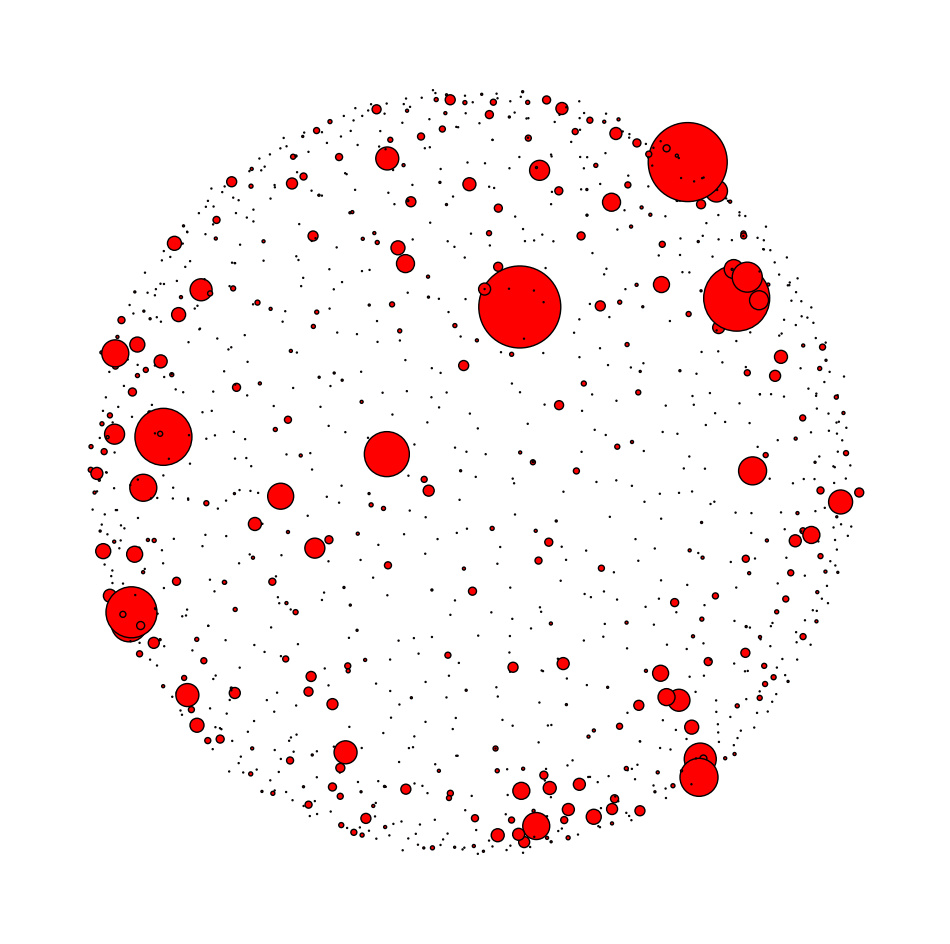

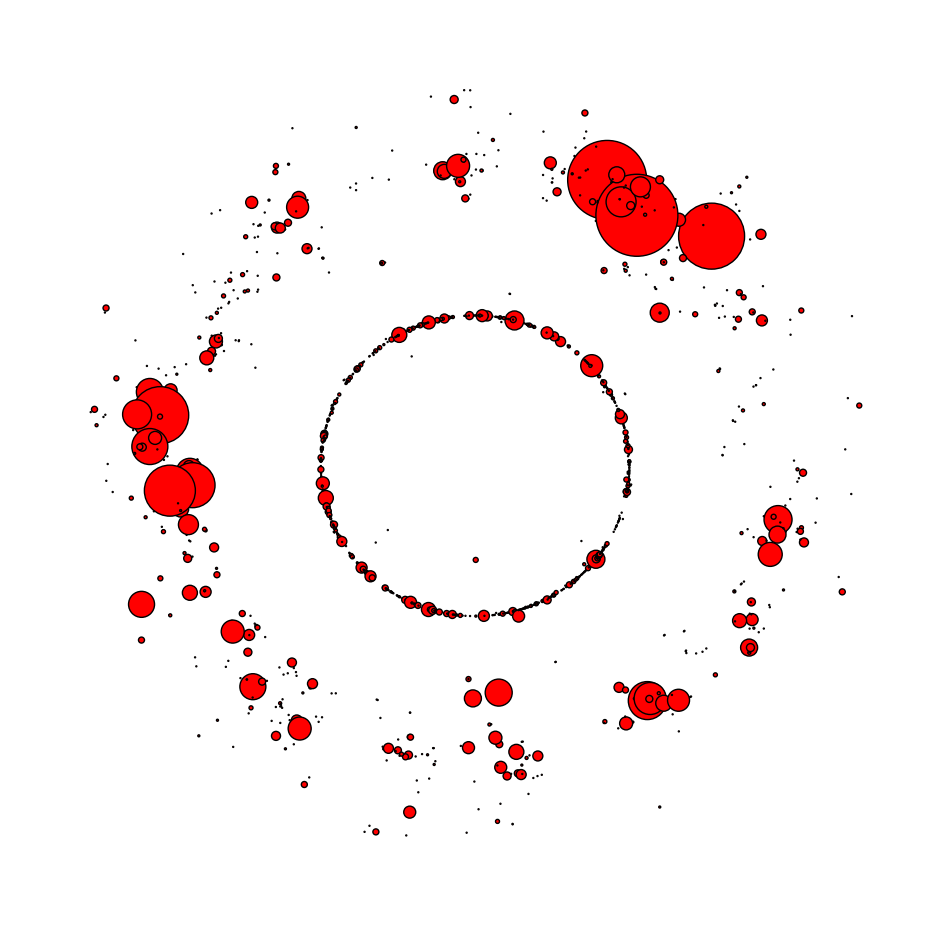

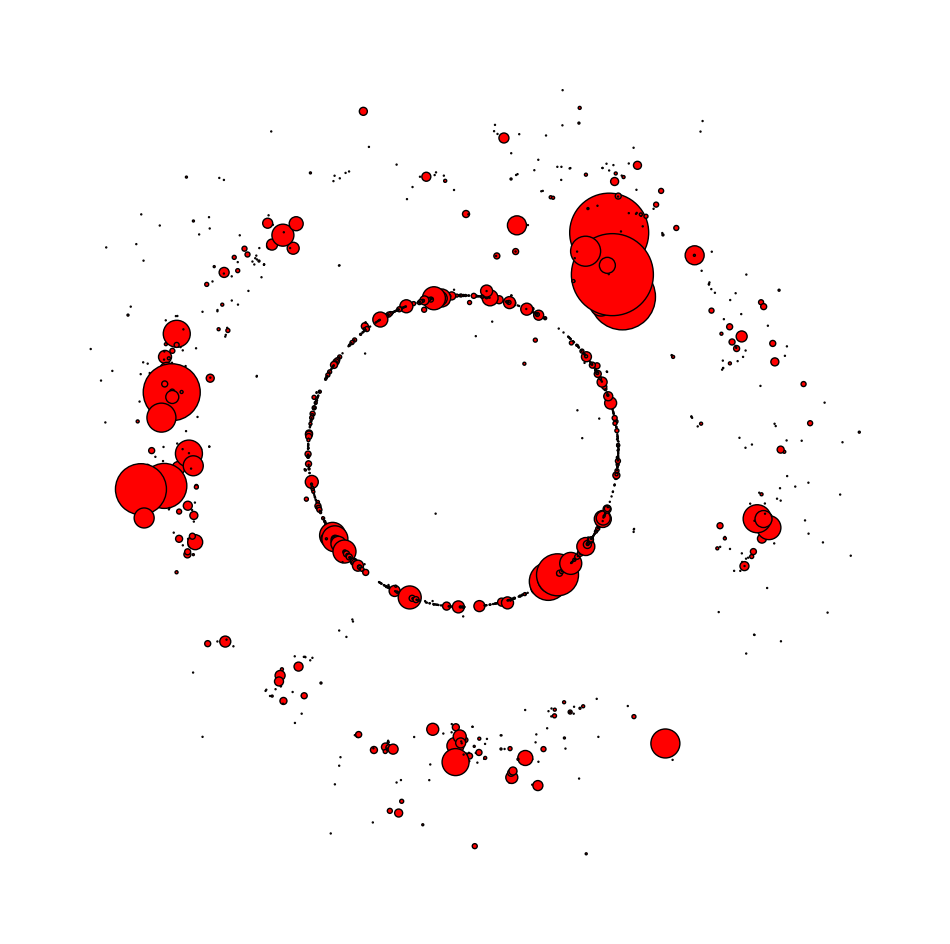

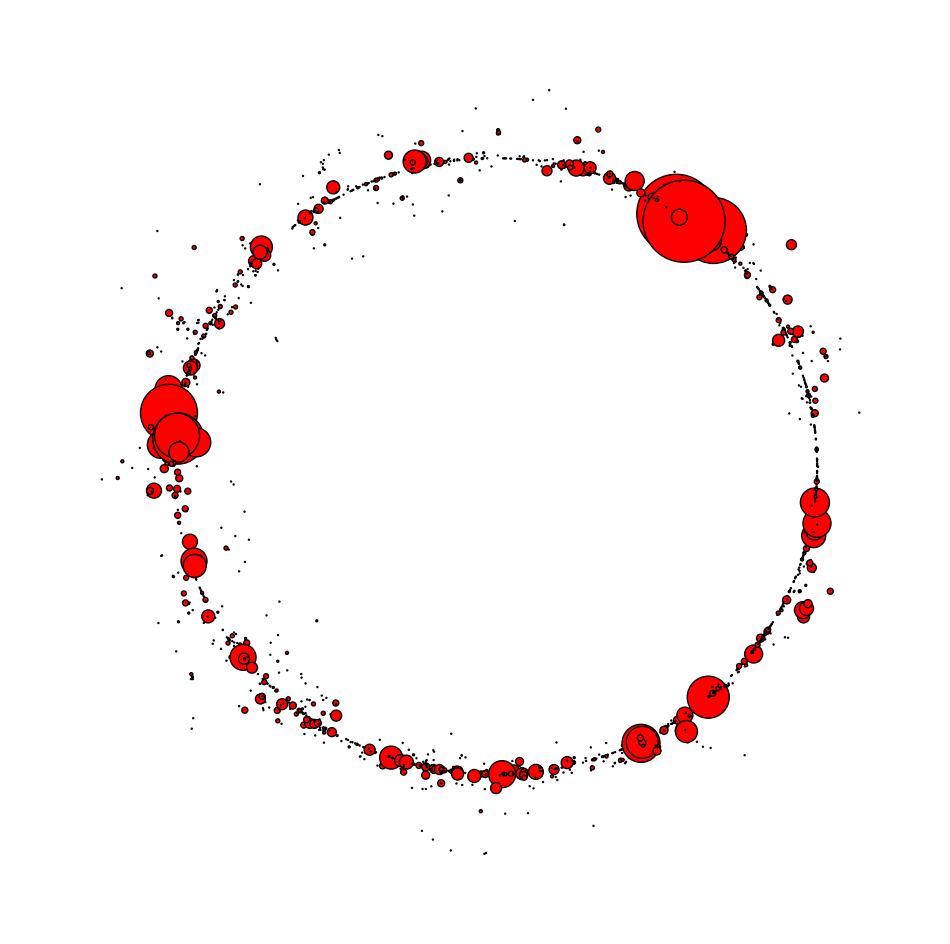

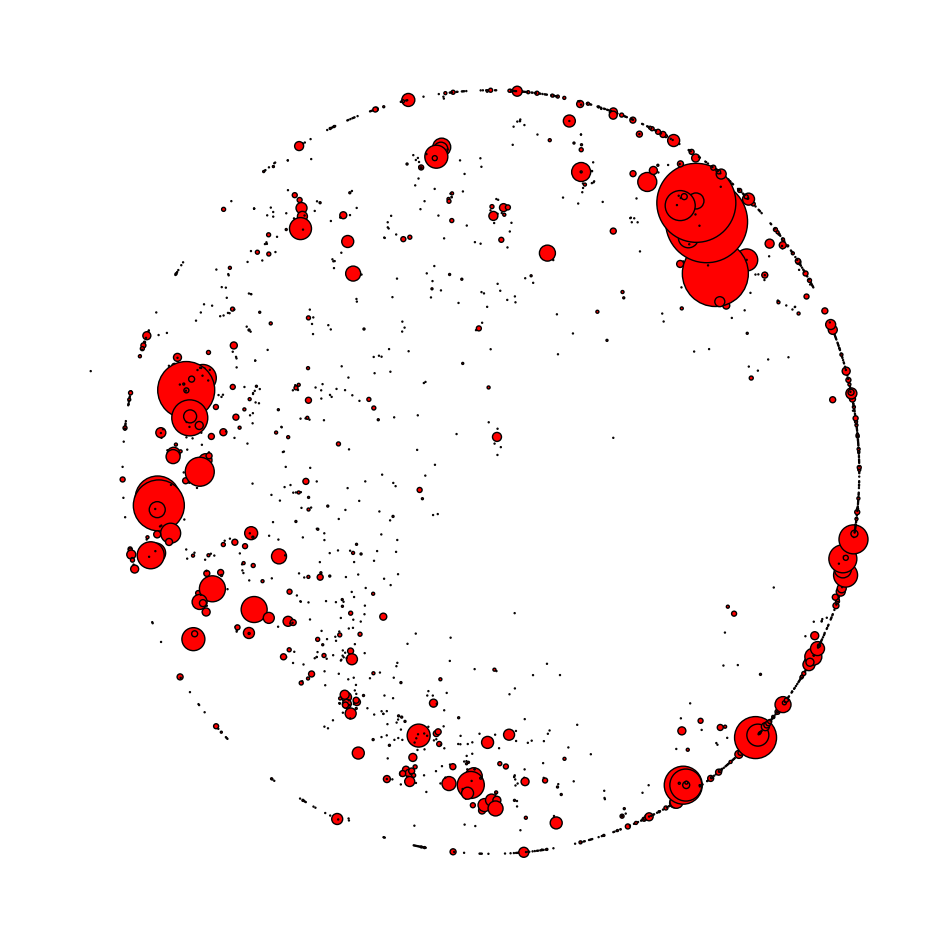

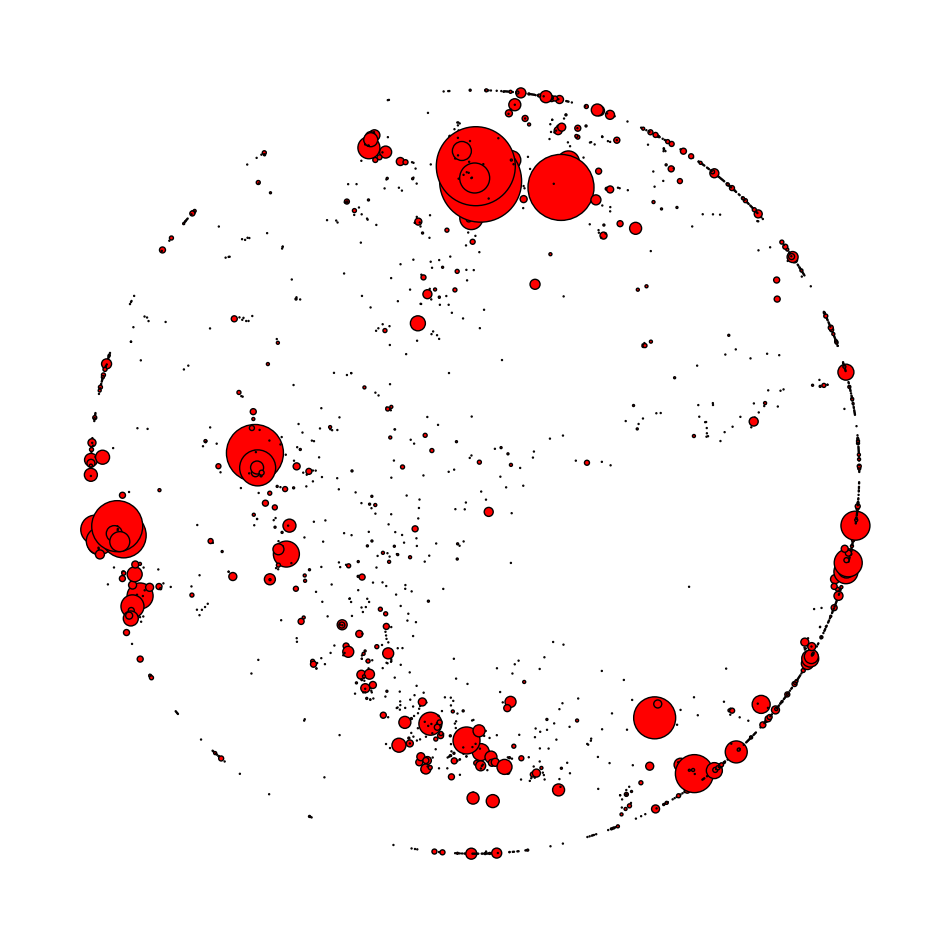

In [183]:
import igraph as ig
import matplotlib.pyplot as plt

for stationsPairsLimited in stationParisLimitedPerRadius:
    g = ig.Graph.TupleList(stationsPairsLimited.itertuples(index=False), weights=True)

    node_sizes = dict(zip(stationsLimited["posid"], stationsLimited["total_amt"].apply(lambda x: x / 100000)))

    g.vs["size"] = [node_sizes.get(posid, 1) for posid in g.vs["name"]]

    layout = g.layout("kamada_kawai", weights=g.es["weight"])

    fig, ax = plt.subplots(figsize=(12, 12))  # Larger figure size for better visualization
    ig.plot(g, layout=layout, target=ax, vertex_size=g.vs["size"], bbox=(0, 0, 1000, 1000), edge_width=0)

    plt.show()



## Number of stations in 50 km radius and the amnt

In [184]:
stationInRadiusPerRadius = []
for stationsPairsLimited in stationParisLimitedPerRadius:
    stationDistances = pd.melt(stationsPairsLimited, id_vars=['distance'], value_vars=['posid_1', 'posid_2'], 
                  var_name='pos_type', value_name='posid')

    stationDistances = stationDistances.drop('pos_type', axis=1)

    stationsInRadius = stationDistances.groupby("posid").agg(
        stations_in_radius=("distance", "count"),
        posid=("posid", "first")
    )

    stationsInRadius = stationsInRadius.set_index("posid").join(stationsWithDifferingGPS.set_index("posid"))
    stationsInRadius = stationsInRadius.drop(columns=["gps_lat", "gps_lon"])
    stationsInRadius = stationsInRadius.sort_values(by="total_amt")
    stationInRadiusPerRadius.append(stationsInRadius)

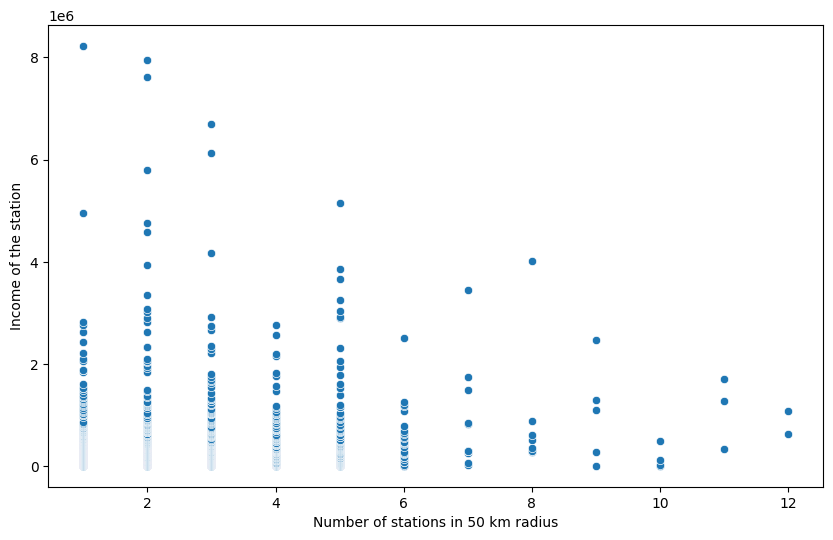

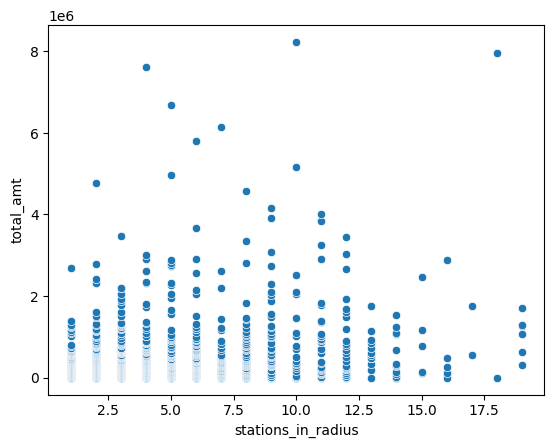

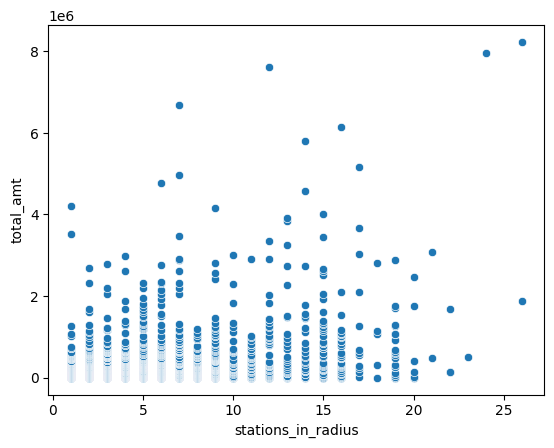

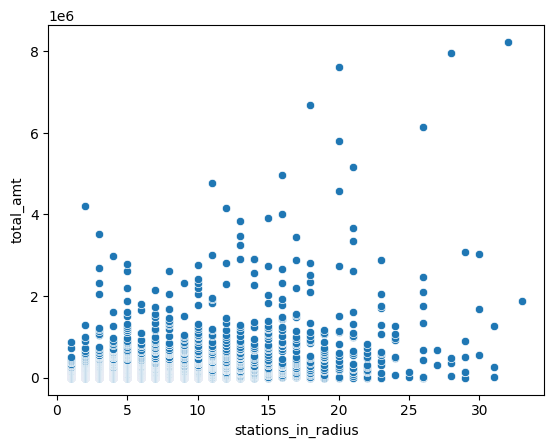

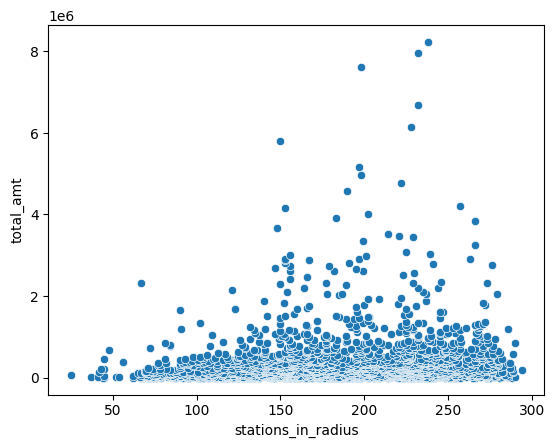

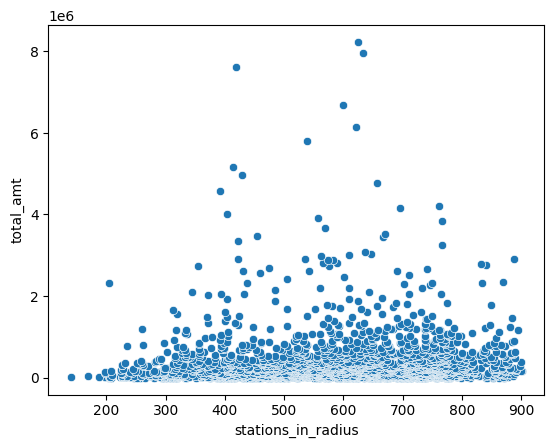

In [185]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
plt.xlabel('Number of stations in 50 km radius')
plt.ylabel('Income of the station')

for stationsInRadius in stationInRadiusPerRadius:
    sns.scatterplot(x='stations_in_radius', y='total_amt', data=stationsInRadius)
    plt.show()

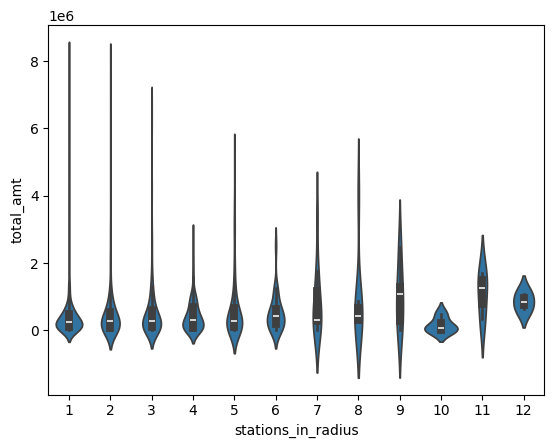

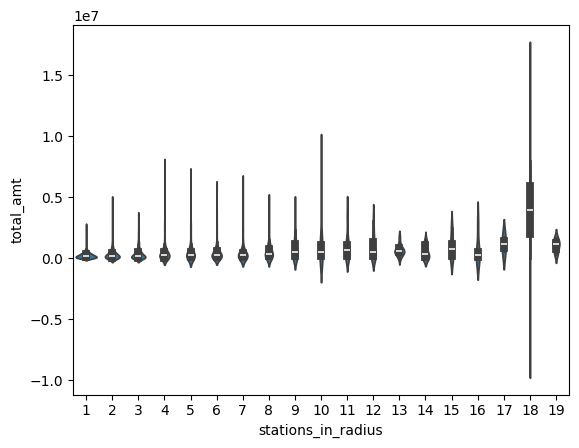

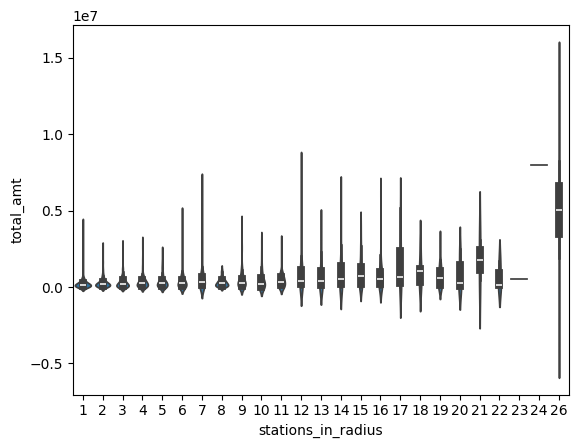

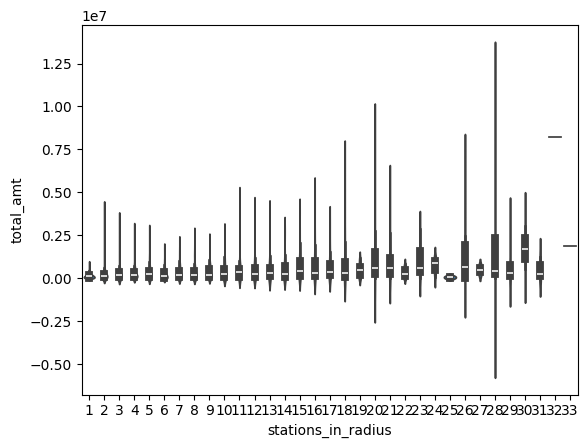

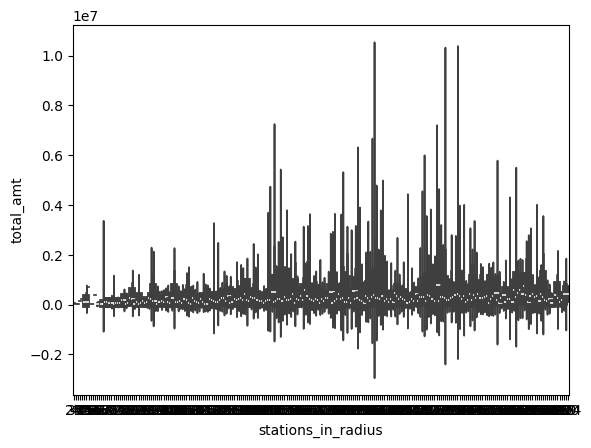

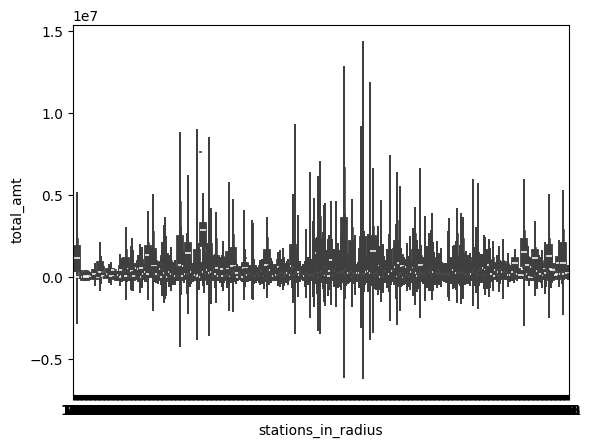

In [186]:
for stationsInRadius in stationInRadiusPerRadius:
    sns.violinplot(x='stations_in_radius', y='total_amt', data=stationsInRadius)
    plt.show()

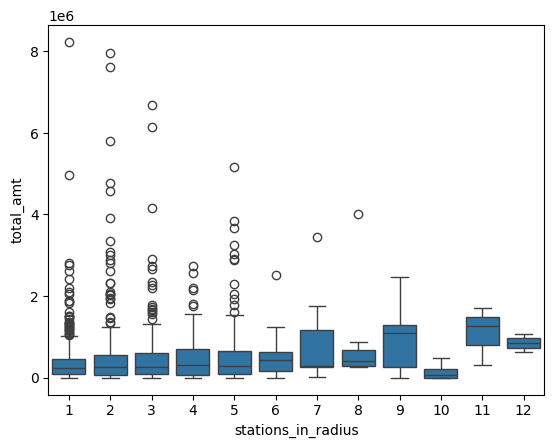

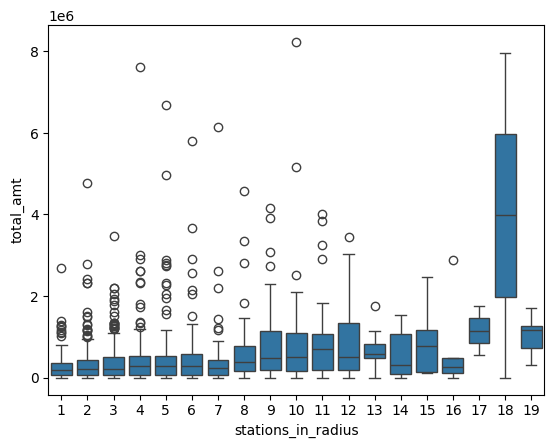

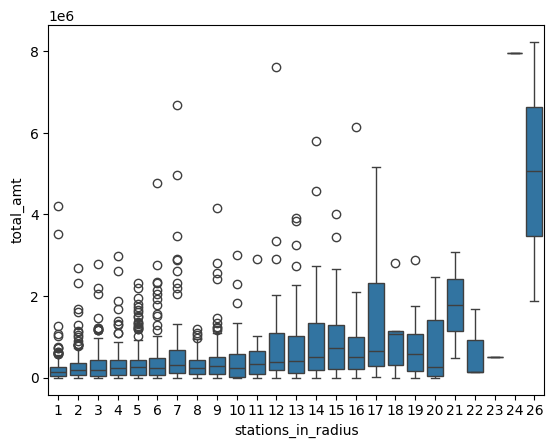

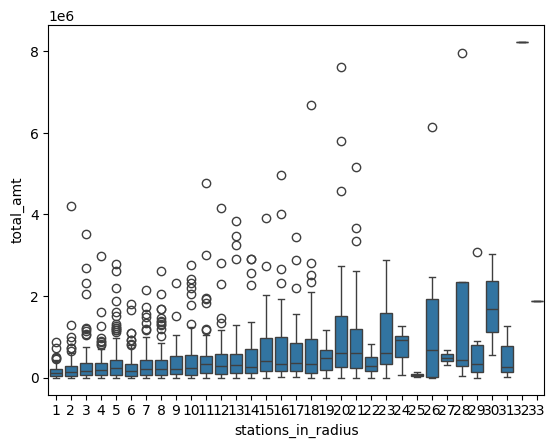

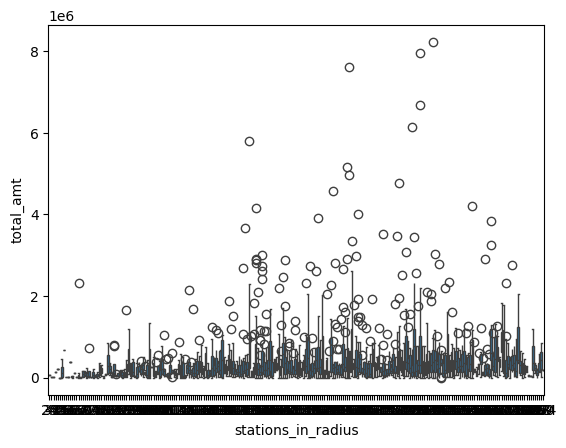

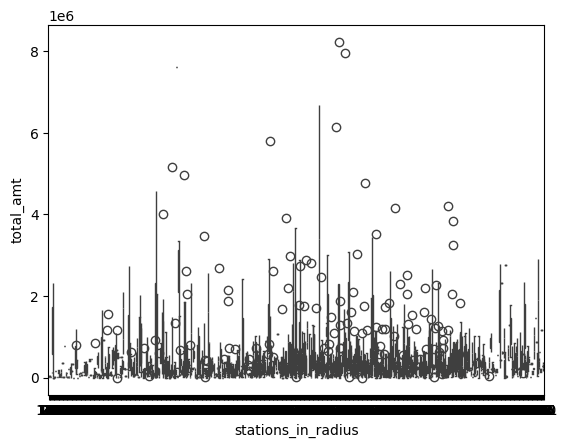

In [187]:
for stationsInRadius in stationInRadiusPerRadius:
    sns.boxplot(x='stations_in_radius', y='total_amt', data=stationsInRadius)
    plt.show()

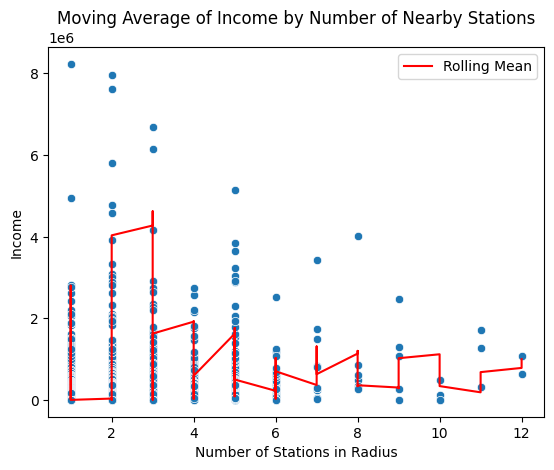

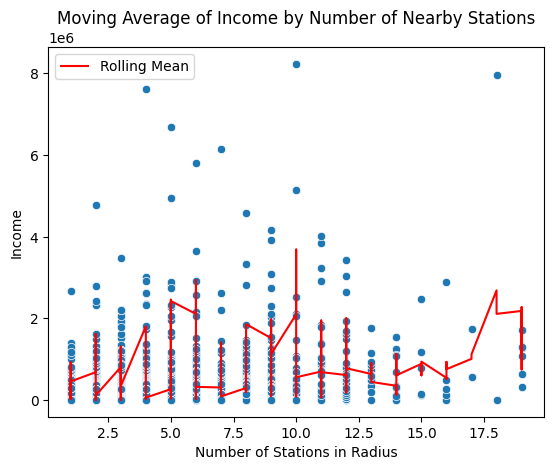

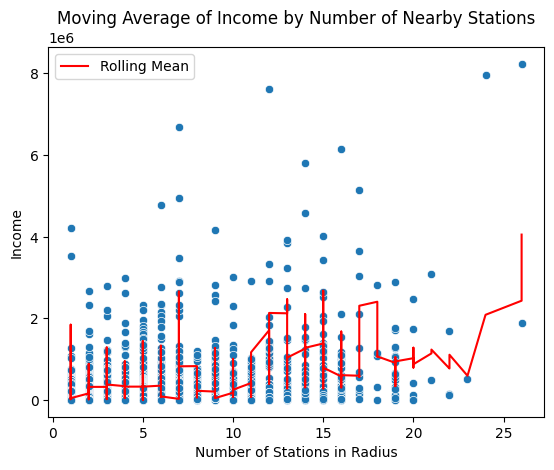

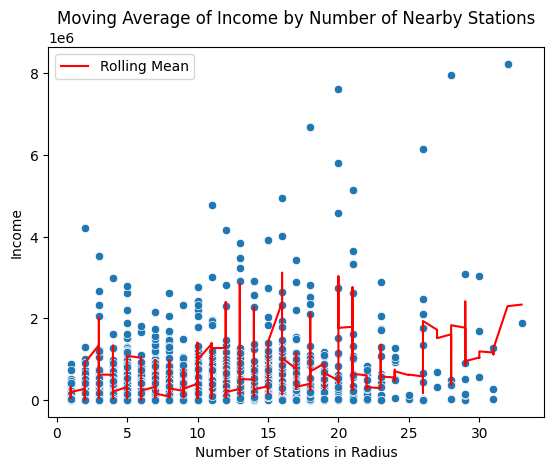

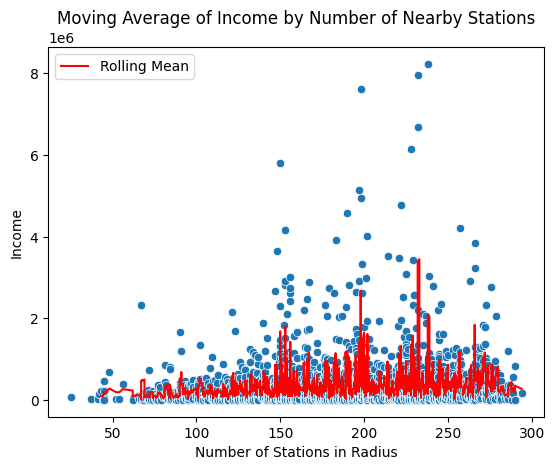

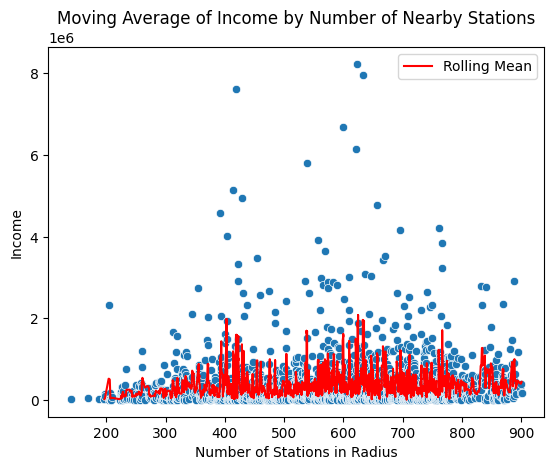

In [188]:
for stationsInRadius in stationInRadiusPerRadius:
    stationsInRadius.sort_values(by='stations_in_radius', inplace=True)
    stationsInRadius['rolling_mean'] = stationsInRadius['total_amt'].rolling(window=5).mean()

    plt.plot(stationsInRadius['stations_in_radius'], stationsInRadius['rolling_mean'], label='Rolling Mean', color='red')
    sns.scatterplot(x='stations_in_radius', y='total_amt', data=stationsInRadius)
    plt.xlabel('Number of Stations in Radius')
    plt.ylabel('Income')
    plt.title('Moving Average of Income by Number of Nearby Stations')
    plt.legend()
    plt.show()

C:\Users\asus\AppData\Local\Temp\ipykernel_2712\2297747729.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


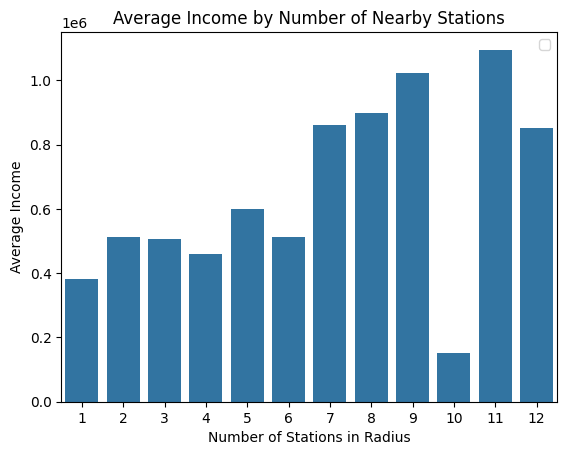

C:\Users\asus\AppData\Local\Temp\ipykernel_2712\2297747729.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


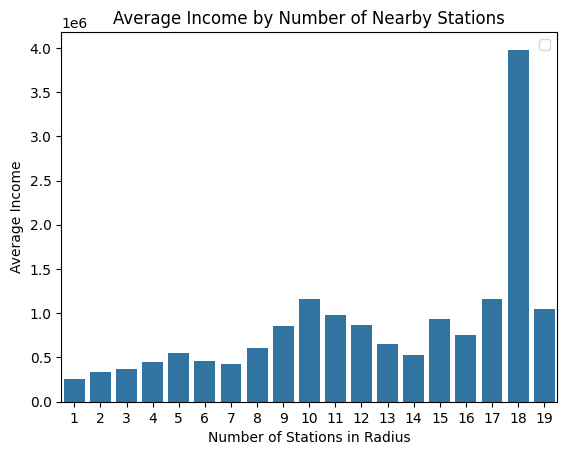

C:\Users\asus\AppData\Local\Temp\ipykernel_2712\2297747729.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


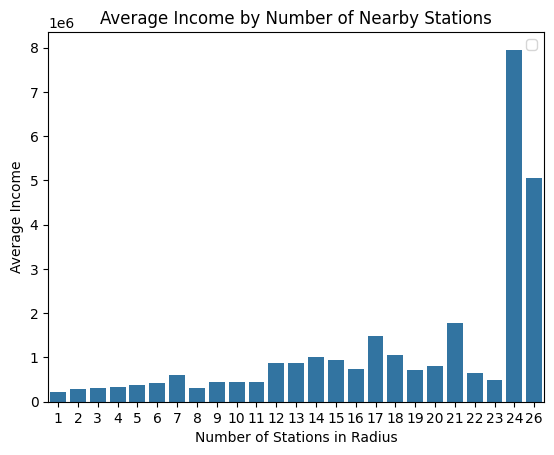

C:\Users\asus\AppData\Local\Temp\ipykernel_2712\2297747729.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


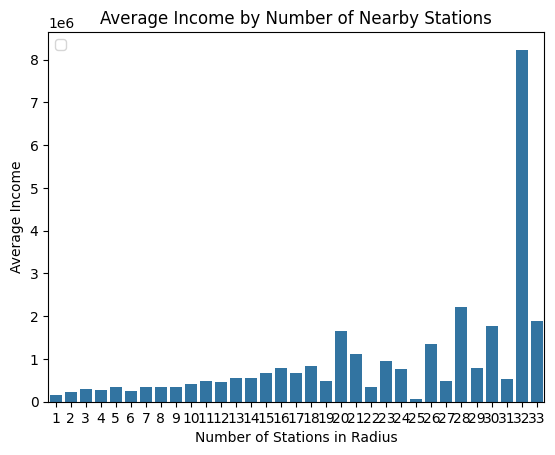

C:\Users\asus\AppData\Local\Temp\ipykernel_2712\2297747729.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


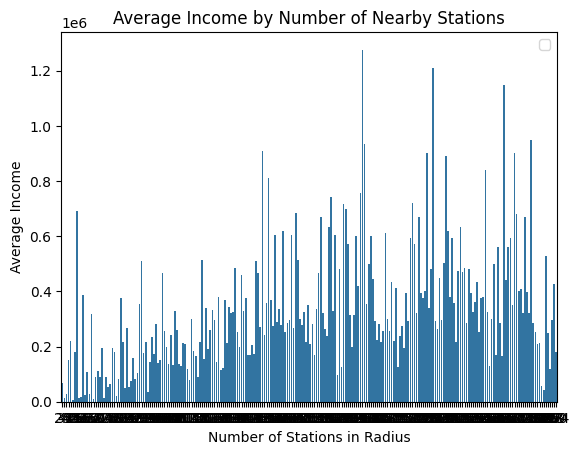

C:\Users\asus\AppData\Local\Temp\ipykernel_2712\2297747729.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


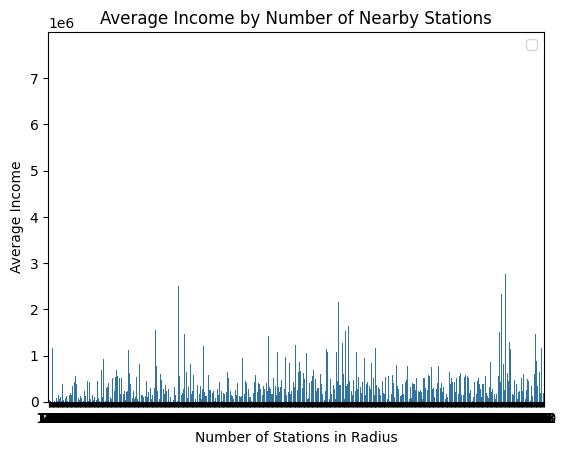

In [189]:
for stationsInRadius in stationInRadiusPerRadius:
    aggregated = stationsInRadius.groupby('stations_in_radius')['total_amt'].mean().reset_index()
    sns.barplot(x='stations_in_radius', y='total_amt', data=aggregated)
    plt.xlabel('Number of Stations in Radius')
    plt.ylabel('Average Income')
    plt.title('Average Income by Number of Nearby Stations')
    plt.legend()
    plt.show()

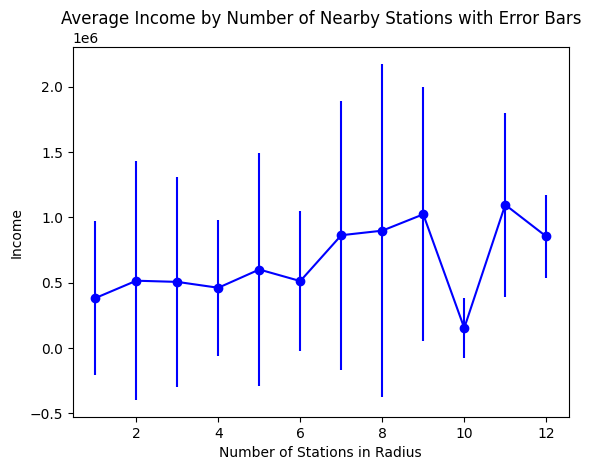

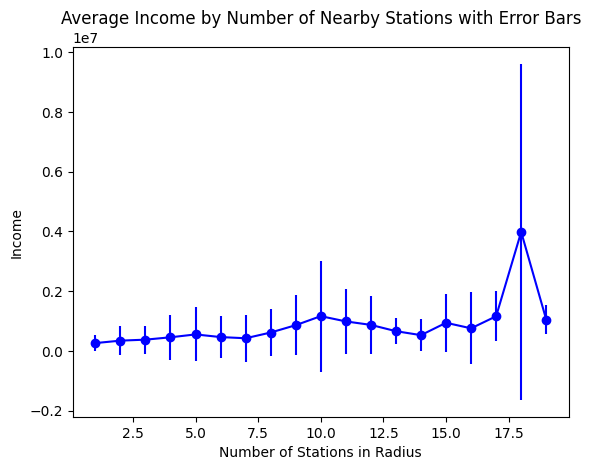

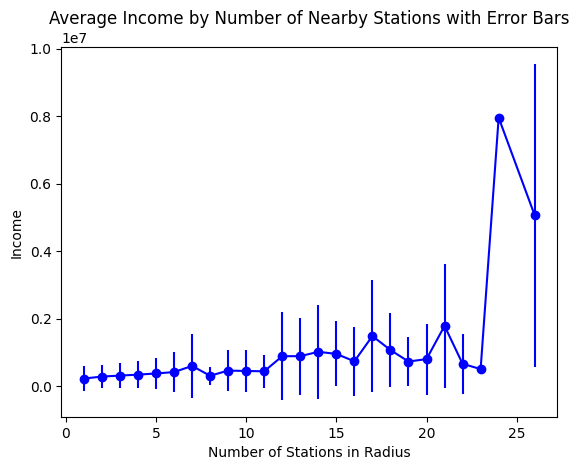

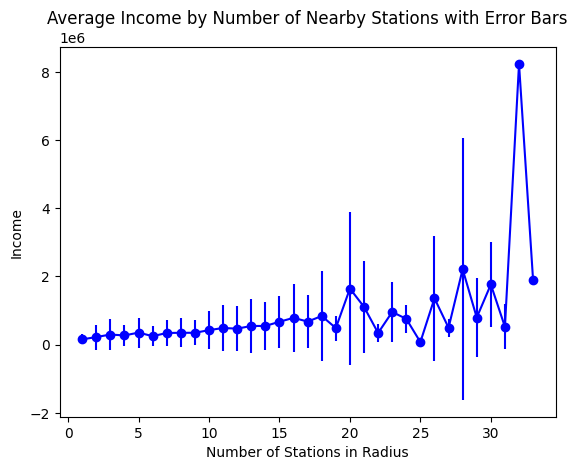

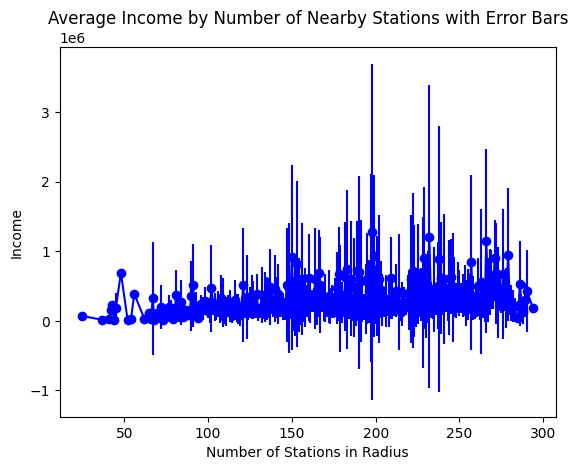

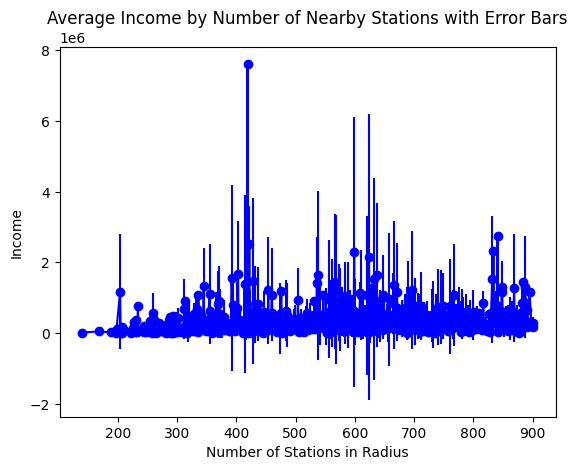

In [190]:
for stationsInRadius in stationInRadiusPerRadius:
    aggregated = stationsInRadius.groupby('stations_in_radius')['total_amt'].agg(['mean', 'std']).reset_index()
    plt.errorbar(aggregated['stations_in_radius'], aggregated['mean'], yerr=aggregated['std'], fmt='o-', color='blue')
    plt.xlabel('Number of Stations in Radius')
    plt.ylabel('Income')
    plt.title('Average Income by Number of Nearby Stations with Error Bars')
    plt.show()

c:\Users\asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\distributions.py:413: UserWarning: `bins` cannot be 'auto' when using weights. Setting `bins=10`, but you will likely want to adjust.
  warnings.warn(msg, UserWarning)


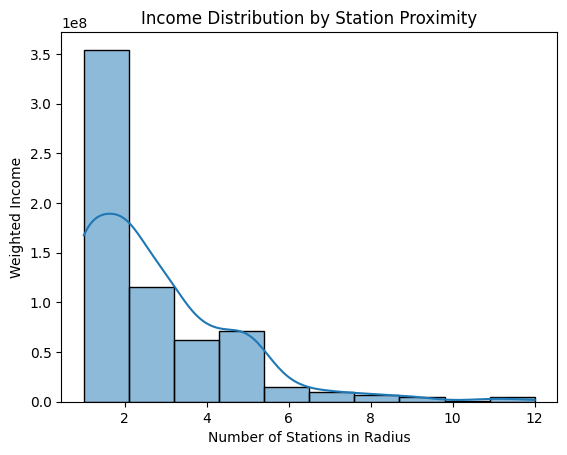

c:\Users\asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\distributions.py:413: UserWarning: `bins` cannot be 'auto' when using weights. Setting `bins=10`, but you will likely want to adjust.
  warnings.warn(msg, UserWarning)


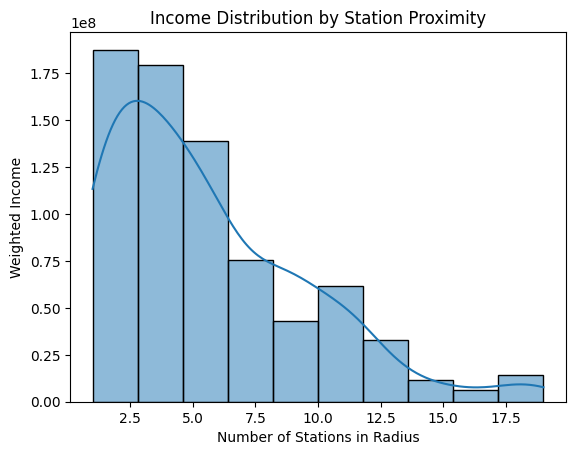

c:\Users\asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\distributions.py:413: UserWarning: `bins` cannot be 'auto' when using weights. Setting `bins=10`, but you will likely want to adjust.
  warnings.warn(msg, UserWarning)


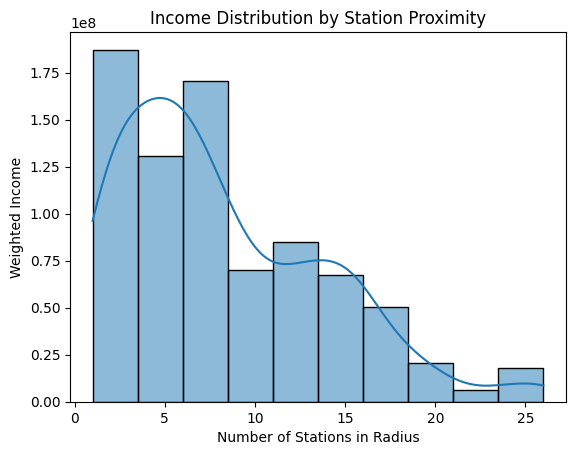

c:\Users\asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\distributions.py:413: UserWarning: `bins` cannot be 'auto' when using weights. Setting `bins=10`, but you will likely want to adjust.
  warnings.warn(msg, UserWarning)


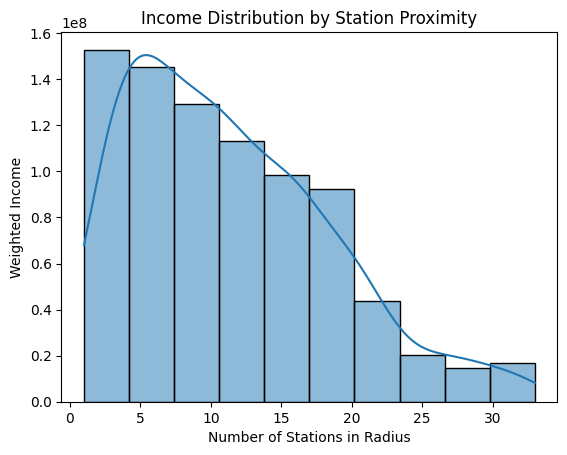

c:\Users\asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\distributions.py:413: UserWarning: `bins` cannot be 'auto' when using weights. Setting `bins=10`, but you will likely want to adjust.
  warnings.warn(msg, UserWarning)


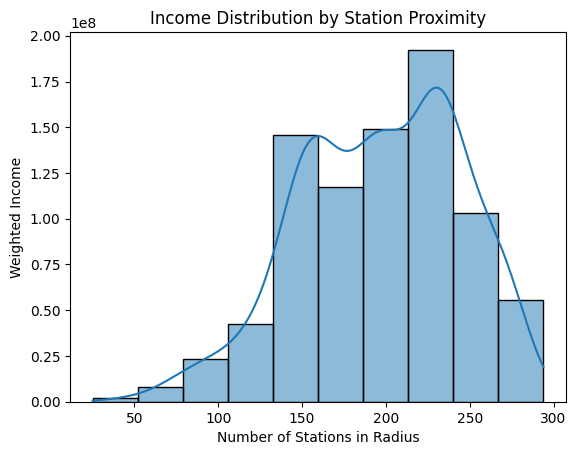

c:\Users\asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\distributions.py:413: UserWarning: `bins` cannot be 'auto' when using weights. Setting `bins=10`, but you will likely want to adjust.
  warnings.warn(msg, UserWarning)


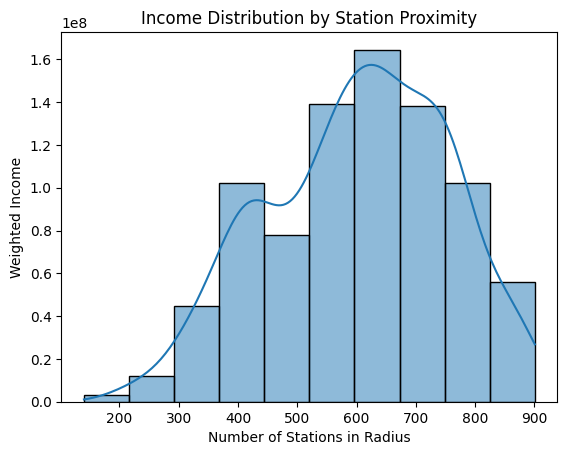

In [191]:
for stationsInRadius in stationInRadiusPerRadius:
    sns.histplot(data=stationsInRadius, x='stations_in_radius', weights='total_amt', kde=True)
    plt.xlabel('Number of Stations in Radius')
    plt.ylabel('Weighted Income')
    plt.title('Income Distribution by Station Proximity')
    plt.show()

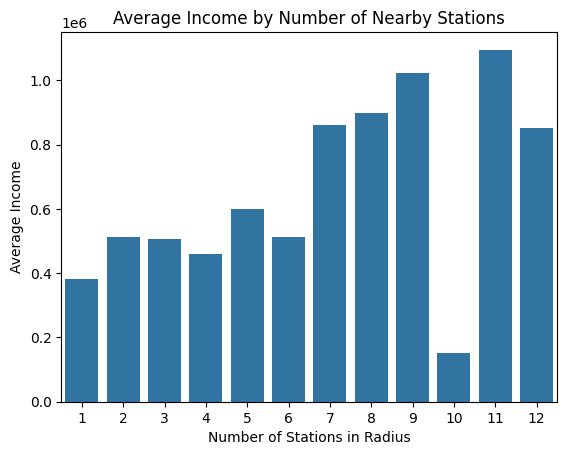

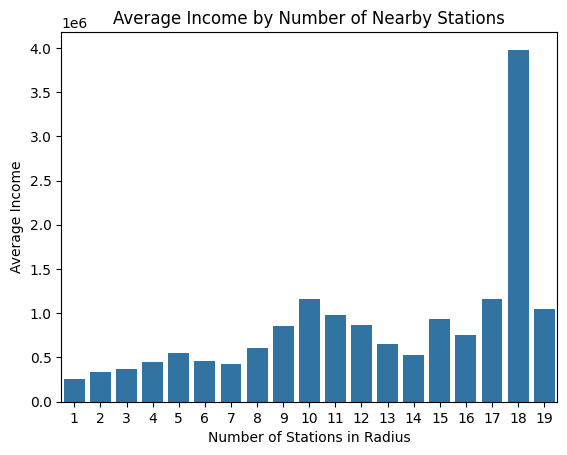

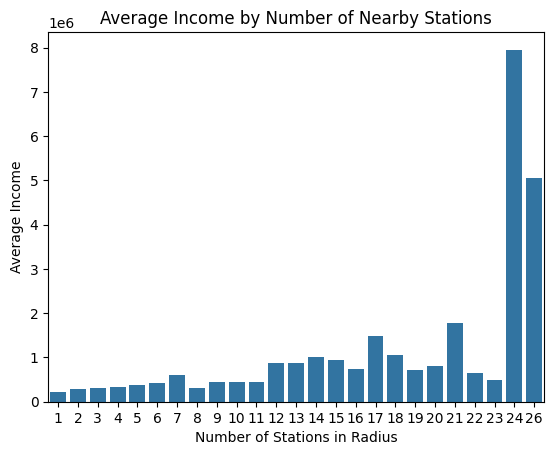

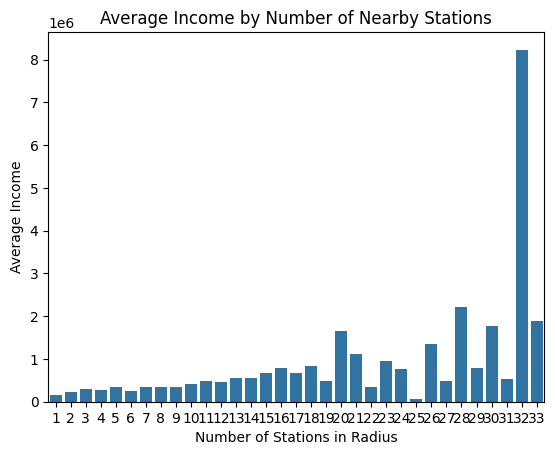

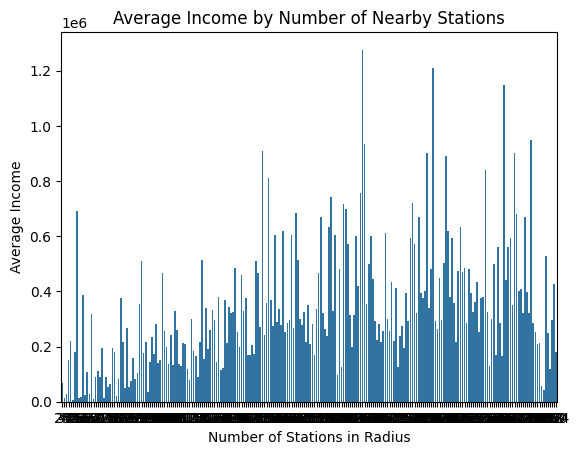

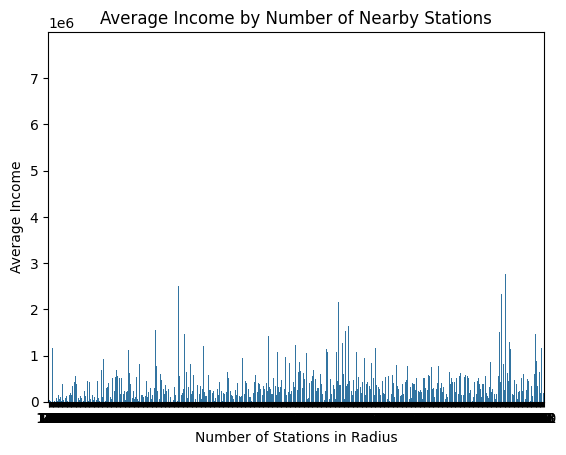

In [192]:
for stationsInRadius in stationInRadiusPerRadius:
    aggregated = stationsInRadius.groupby('stations_in_radius')['total_amt'].mean().reset_index()
    sns.barplot(x='stations_in_radius', y='total_amt', data=aggregated)
    plt.xlabel('Number of Stations in Radius')
    plt.ylabel('Average Income')
    plt.title('Average Income by Number of Nearby Stations')
    plt.show()